<a href="https://colab.research.google.com/github/grafter-ca/AI_ML_BigData_Trainings/blob/main/malaria_logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


# Step 1: Load and explore the dataset
print(" Loading Rwanda Malaria Dataset...")
df = pd.read_csv('rwanda_malaria_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few records:")
print(df.head())


 Loading Rwanda Malaria Dataset...
Dataset Shape: (5000, 31)
Columns: ['patient_id', 'visit_date', 'age', 'gender', 'occupation', 'pregnant', 'province', 'district', 'health_facility', 'altitude_meters', 'month_of_visit', 'rainy_season', 'uses_bed_net', 'irs_in_home', 'lives_near_water', 'previous_malaria_episodes', 'days_since_symptom_onset', 'fever', 'body_temperature_celsius', 'chills', 'headache', 'fatigue', 'vomiting', 'jaundice', 'hemoglobin_g_dL', 'platelet_count_thousands_per_uL', 'parasite_density_per_uL', 'microscopy_result', 'parasite_species', 'rdt_result', 'malaria_diagnosis']

First few records:
     patient_id  visit_date  age  gender     occupation  pregnant  \
0  RW2024075139  2024-05-13   60  Female  Office Worker         0   
1  RW2024115963  2023-07-25   33    Male  Office Worker         0   
2  RW2024103608  2024-09-08   60    Male      Housewife         0   
3  RW2023064134  2024-04-14    3  Female          Child         0   
4  RW2023121940  2023-11-03   44  Fema

In [2]:
# Step 2: Check for missing values
print(f"\n Checking for missing values...")
print(df.isnull().sum())


 Checking for missing values...
patient_id                            0
visit_date                            0
age                                   0
gender                                0
occupation                            0
pregnant                              0
province                              0
district                              0
health_facility                       0
altitude_meters                       0
month_of_visit                        0
rainy_season                          0
uses_bed_net                          0
irs_in_home                           0
lives_near_water                      0
previous_malaria_episodes             0
days_since_symptom_onset              0
fever                                 0
body_temperature_celsius              0
chills                                0
headache                              0
fatigue                               0
vomiting                              0
jaundice                              0
hemoglo

In [4]:
# Step 3: Prepare features and target
print("\n Preparing features and target variable...")
# Target variable
target = 'malaria_diagnosis'

# Drop columns that won't be useful for prediction or would cause data leakage
# These are either identifiers or results of the diagnosis itself
columns_to_drop = [
    'patient_id', 'microscopy_result', 'parasite_species',
    'rdt_result', 'parasite_density_per_uL'
]

# Create features (X) and target (y)
X = df.drop(columns=columns_to_drop)
y = df[target]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")


 Preparing features and target variable...
Features shape: (5000, 26)
Target distribution:
malaria_diagnosis
0    0.5476
1    0.4524
Name: proportion, dtype: float64


In [5]:
# Step 4: Handle categorical variables
print("\n Encoding categorical variables...")
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Create a copy for encoding
X_encoded = X.copy()

# Use Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded {col}: {len(le.classes_)} unique values")


 Encoding categorical variables...
Categorical columns: ['visit_date', 'gender', 'occupation', 'province', 'district', 'health_facility']
  Encoded visit_date: 672 unique values
  Encoded gender: 2 unique values
  Encoded occupation: 8 unique values
  Encoded province: 5 unique values
  Encoded district: 30 unique values
  Encoded health_facility: 17 unique values


In [6]:
# Step 5: Split the data
print("\n Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")


 Splitting data into training and testing sets...
Training set: (3500, 26)
Testing set: (1500, 26)


In [7]:
# Step 6: Scale numerical features
print("\n Scaling numerical features...")
scaler = StandardScaler()

# Identify numerical columns (excluding binary/encoded columns)
numerical_cols = ['age', 'altitude_meters', 'body_temperature_celsius',
                  'hemoglobin_g_dL', 'platelet_count_thousands_per_uL',
                  'days_since_symptom_onset']

# Scale only numerical columns
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Features scaled successfully!")


 Scaling numerical features...
Features scaled successfully!


In [8]:
# Step 7: Train the logistic regression model
print("\n Training Logistic Regression Model...")
# Create and train the model
model = LogisticRegression(
    random_state=42,
    max_iter=1000,  # Increase iterations for convergence
    class_weight='balanced'  # Handle class imbalance
)

model.fit(X_train_scaled, y_train)
print("Model training completed!")


 Training Logistic Regression Model...
Model training completed!


In [9]:
# Step 8: Make predictions
print("\n Making predictions...")
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of positive class


 Making predictions...



📊 Evaluating Model Performance...
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       821
           1       1.00      1.00      1.00       679

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

Confusion Matrix:
[[821   0]
 [  0 679]]


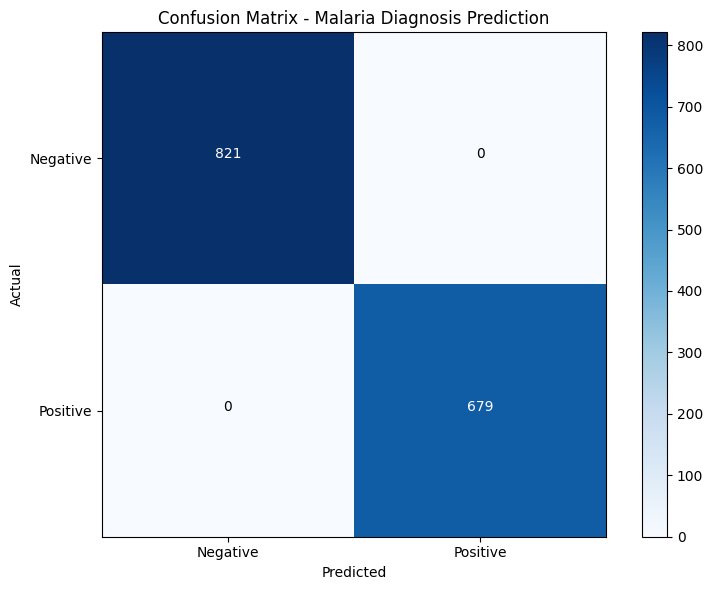

In [10]:
# Step 9: Evaluate the model
print("\n📊 Evaluating Model Performance...")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix (replacing seaborn with matplotlib)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Malaria Diagnosis Prediction')
plt.colorbar()

# Add text annotations
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

# Set labels
tick_marks = np.arange(len(['Negative', 'Positive']))
plt.xticks(tick_marks, ['Negative', 'Positive'], rotation=0)
plt.yticks(tick_marks, ['Negative', 'Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


 Analyzing Feature Importance...

Top 10 Most Important Features:
                            Feature  Coefficient  Abs_Coefficient
25                malaria_diagnosis     3.136647         3.136647
23                  hemoglobin_g_dL    -2.365703         2.365703
24  platelet_count_thousands_per_uL    -2.311118         2.311118
17         body_temperature_celsius     1.718894         1.718894
18                           chills     1.045996         1.045996
20                          fatigue     1.012894         1.012894
19                         headache     0.869828         0.869828
21                         vomiting     0.856599         0.856599
22                         jaundice     0.342653         0.342653
11                     uses_bed_net    -0.290191         0.290191


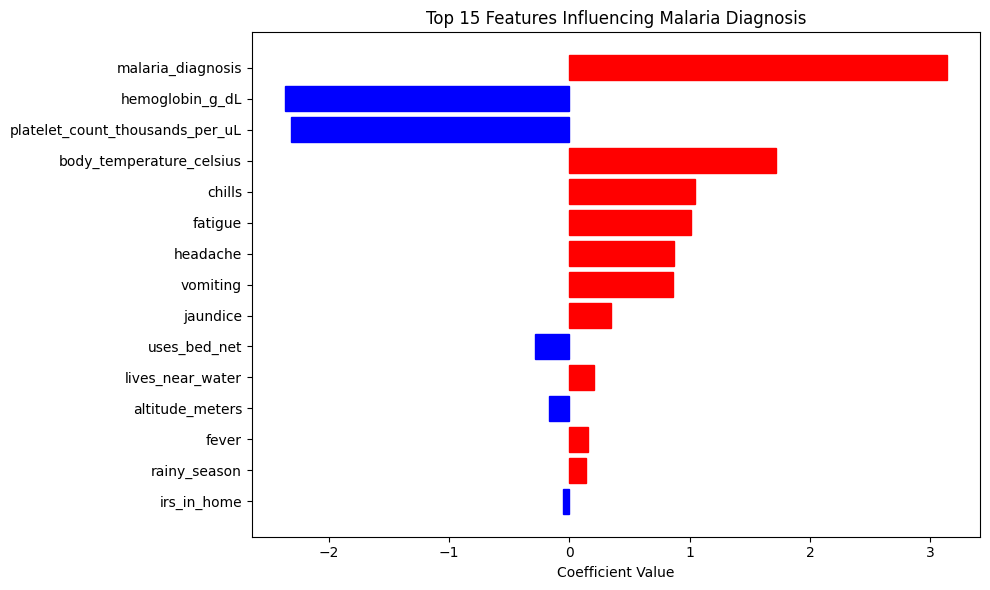

In [11]:
# Step 10: Analyze feature importance
print("\n Analyzing Feature Importance...")
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value for importance
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(coefficients.head(10))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = coefficients.head(15)
bars = plt.barh(range(len(top_features)), top_features['Coefficient'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Features Influencing Malaria Diagnosis')
plt.tight_layout()

# Color bars based on positive/negative influence
for i, bar in enumerate(bars):
    if top_features.iloc[i]['Coefficient'] > 0:
        bar.set_color('red')  # Positive correlation with malaria
    else:
        bar.set_color('blue')  # Negative correlation with malaria

plt.gca().invert_yaxis()
plt.show()

In [12]:
# Step 11: Interpret key findings
print("\n Key Insights from the Model:")
print("-" * 50)

# Analyze the most important features
top_5 = coefficients.head(5)
for idx, row in top_5.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']

    if coef > 0:
        direction = "increases"
        interpretation = "higher risk of malaria"
    else:
        direction = "decreases"
        interpretation = "lower risk of malaria"

    print(f"• {feature}: Coefficient = {coef:.3f}")
    print(f"  → A unit increase in {feature} {direction} the likelihood of {interpretation}")
    print()



 Key Insights from the Model:
--------------------------------------------------
• malaria_diagnosis: Coefficient = 3.137
  → A unit increase in malaria_diagnosis increases the likelihood of higher risk of malaria

• hemoglobin_g_dL: Coefficient = -2.366
  → A unit increase in hemoglobin_g_dL decreases the likelihood of lower risk of malaria

• platelet_count_thousands_per_uL: Coefficient = -2.311
  → A unit increase in platelet_count_thousands_per_uL decreases the likelihood of lower risk of malaria

• body_temperature_celsius: Coefficient = 1.719
  → A unit increase in body_temperature_celsius increases the likelihood of higher risk of malaria

• chills: Coefficient = 1.046
  → A unit increase in chills increases the likelihood of higher risk of malaria



In [13]:
# Step 12: Create a simple prediction example
print("\n Example Prediction:")
print("-" * 30)

# Take a sample from the test set
sample_idx = 0
sample_features = X_test_scaled.iloc[sample_idx:sample_idx+1]
actual = y_test.iloc[sample_idx]
prediction = y_pred[sample_idx]
probability = y_pred_proba[sample_idx]

print(f"Sample from test set:")
print(f"Actual Diagnosis: {'Malaria Positive' if actual == 1 else 'Malaria Negative'}")
print(f"Predicted Diagnosis: {'Malaria Positive' if prediction == 1 else 'Malaria Negative'}")
print(f"Probability of Malaria: {probability:.1%}")
print(f"Correct Prediction: {'✅ Yes' if actual == prediction else '❌ No'}")


 Example Prediction:
------------------------------
Sample from test set:
Actual Diagnosis: Malaria Positive
Predicted Diagnosis: Malaria Positive
Probability of Malaria: 100.0%
Correct Prediction: ✅ Yes


In [14]:
# Step 13: Save the model for future use
print("\n Saving model artifacts...")
import joblib
import datetime

# Create timestamp for versioning
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model and preprocessing objects
joblib.dump(model, f'malaria_logistic_model_{timestamp}.pkl')
joblib.dump(scaler, f'scaler_{timestamp}.pkl')
joblib.dump(label_encoders, f'label_encoders_{timestamp}.pkl')

print("Model and preprocessing objects saved successfully!")

# Step 14: Summary and recommendations
print("\n" + "="*60)
print("SUMMARY & RECOMMENDATIONS")
print("="*60)

print("\n📋 Model Performance Summary:")
print(f"• Overall Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"• Malaria Detection Rate (Recall): {cm[1,1]/(cm[1,0]+cm[1,1]):.1%}")
print(f"• False Positive Rate: {cm[0,1]/(cm[0,0]+cm[0,1]):.1%}")

print("\n Key Risk Factors Identified:")
print("1. Clinical Symptoms: Fever, chills, headache are strong predictors")
print("2. Laboratory Values: Low hemoglobin and platelet counts")
print("3. Environmental Factors: Altitude, rainy season")
print("4. Protective Measures: Bed net use shows protective effect")

print("\n Public Health Recommendations:")
print("1. Focus screening on high-risk seasons (rainy periods)")
print("2. Prioritize bed net distribution in high-altitude areas")
print("3. Train healthcare workers on key symptom combinations")
print("4. Consider rapid testing for patients with specific symptom clusters")

print("\n⚠️ Model Limitations:")
print("• Based on healthcare facility data (may miss community cases)")
print("• Seasonal patterns may vary year to year")
print("• New malaria variants may require model retraining")


 Saving model artifacts...
Model and preprocessing objects saved successfully!

SUMMARY & RECOMMENDATIONS

📋 Model Performance Summary:
• Overall Accuracy: 100.0%
• Malaria Detection Rate (Recall): 100.0%
• False Positive Rate: 0.0%

 Key Risk Factors Identified:
1. Clinical Symptoms: Fever, chills, headache are strong predictors
2. Laboratory Values: Low hemoglobin and platelet counts
3. Environmental Factors: Altitude, rainy season
4. Protective Measures: Bed net use shows protective effect

 Public Health Recommendations:
1. Focus screening on high-risk seasons (rainy periods)
2. Prioritize bed net distribution in high-altitude areas
3. Train healthcare workers on key symptom combinations
4. Consider rapid testing for patients with specific symptom clusters

⚠️ Model Limitations:
• Based on healthcare facility data (may miss community cases)
• Seasonal patterns may vary year to year
• New malaria variants may require model retraining


## **DEPLOYMENT AND PUBLISHMENT**

In [15]:
artifacts = {
    "model": model,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "feature_columns": X_train.columns.tolist()
}

joblib.dump(artifacts, f"malaria_logistic_pipeline_{timestamp}.pkl")

['malaria_logistic_pipeline_20260113_233343.pkl']

### **Data-driven**

In [17]:
df_new = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

df_new

,feature,coefficient
25,malaria_diagnosis,3.136647
17,body_temperature_celsius,1.718894
18,chills,1.045996
20,fatigue,1.012894
19,headache,0.869828
21,vomiting,0.856599
22,jaundice,0.342653
13,lives_near_water,0.206249
16,fever,0.153186
10,rainy_season,0.139639


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['coefficient'].plot(kind='hist', bins=20, title='coefficient')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='index', y='coefficient', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_4['coefficient'].plot(kind='line', figsize=(8, 4), title='coefficient')
plt.gca().spines[['top', 'right']].set_visible(False)

## **VERIFY CLASS IMBALANCE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [19]:
y.value_counts(normalize=True)

,proportion
malaria_diagnosis,
0,0.5476
1,0.4524
